# Correlation on Episode Outcomes

In [1]:
import json
import pandas as pd
import plotly.express as px
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def plot_correlation(correlation, runid, ax):
    # Create a heatmap of the correlation matrix with annotations
    mask = np.tril(np.ones_like(correlation, dtype=bool))
    sns.heatmap(
        correlation,
        mask=mask,
        annot=True,
        fmt=".4f",
        cmap="bwr",
        cbar=True,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor="black",
        ax=ax,
    )
    # plt.title(f"Spearman Correlation Matrix for {runid}")

File: data/lifting_trials_jckeurhl_lhs_1000_rl_model_20000000_steps.txt
Average Success Rate: 0.981
Average Tip Rate: 0.01
Average Slip Rate: 0.009
Sanity Check: 1.0



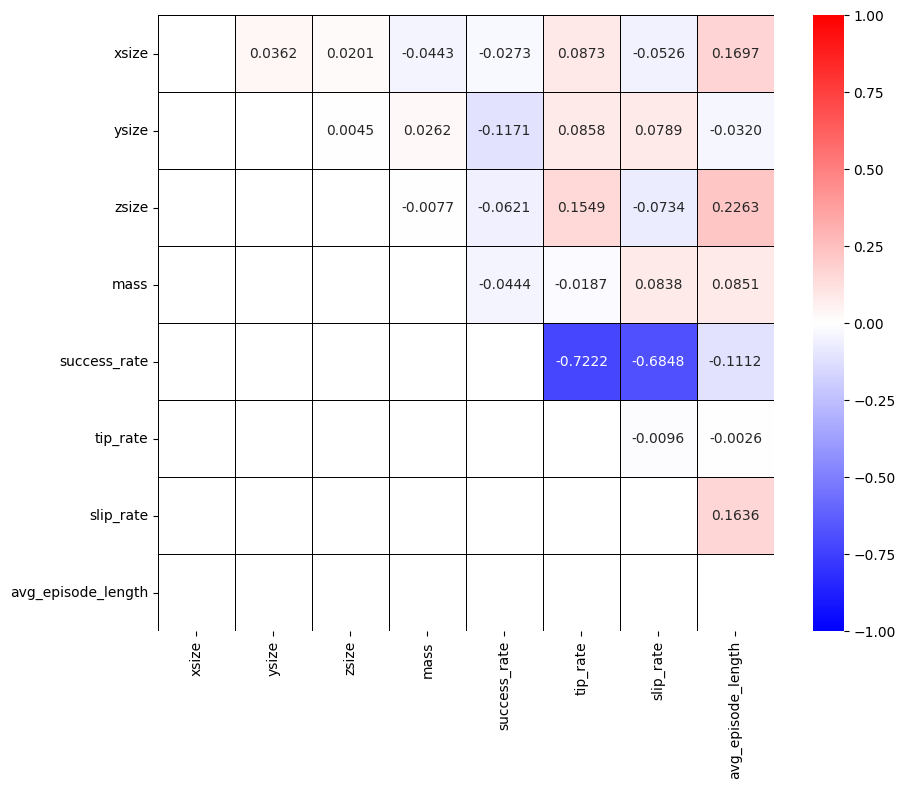

File: data/lifting_trials_jckeurhl_lhs_1000_rl_model_10000000_steps.txt
Average Success Rate: 0.97
Average Tip Rate: 0.017
Average Slip Rate: 0.013
Sanity Check: 1.0



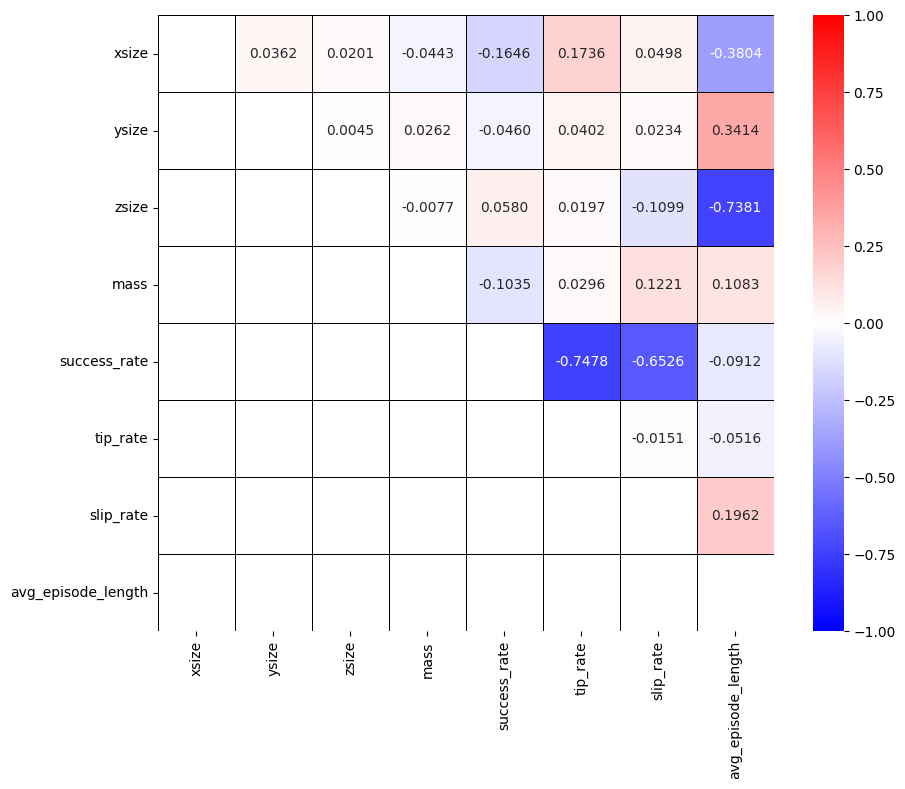

File: data/lifting_trials_27vo09mu_lhs_1000_rl_model_20000000_steps.txt
Average Success Rate: 0.947
Average Tip Rate: 0.018
Average Slip Rate: 0.035
Sanity Check: 1.0



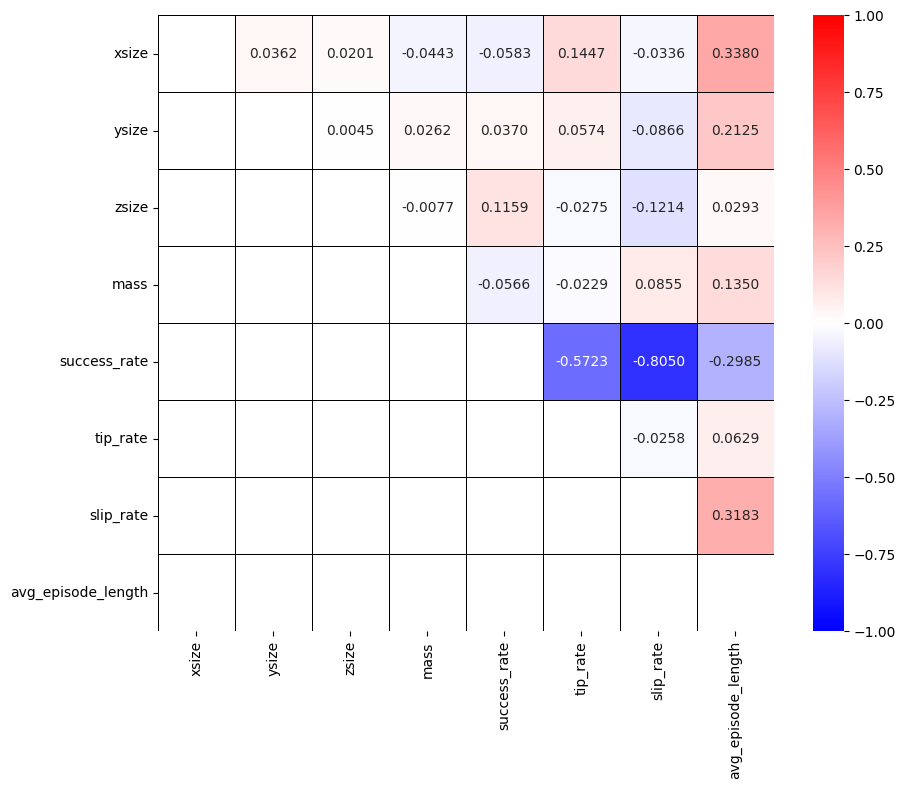

File: data/lifting_trials_baseline_lhs_1000_None.txt
Average Success Rate: 0.876
Average Tip Rate: 0.054
Average Slip Rate: 0.07
Sanity Check: 1.0



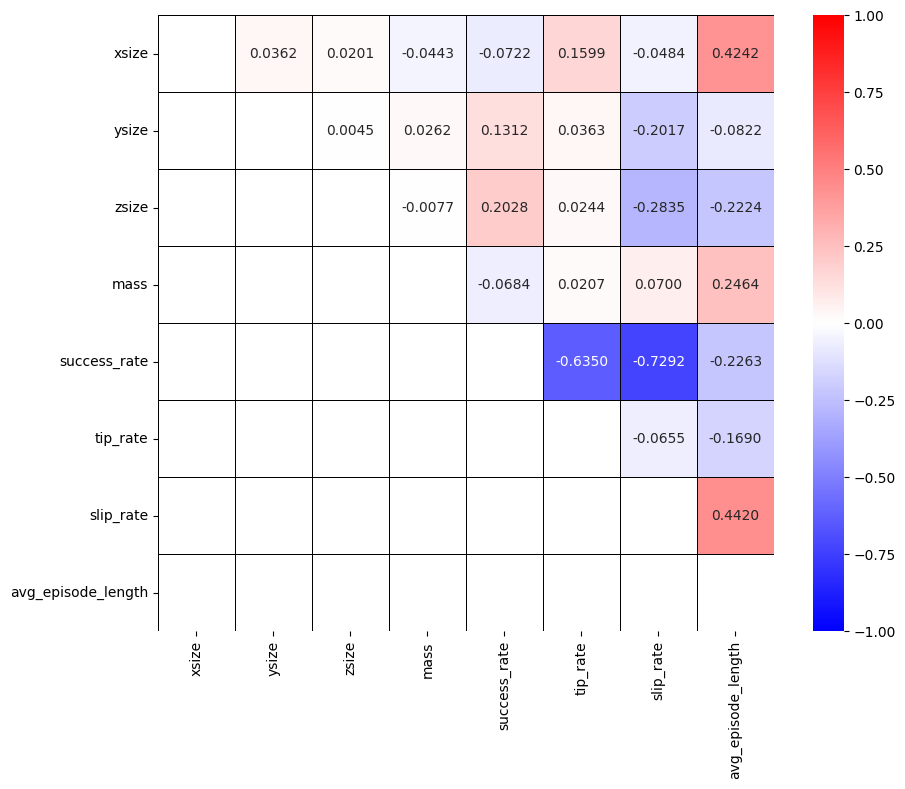

In [3]:
data_files = glob.glob("data/*.txt")
for file_path in data_files:
    # Initialize variables to store the total success rate and the number of trials
    successes = 0
    tips = 0
    slips = 0
    num_trials = 0
    data = []

    # Read the JSON data from the file
    with open(file_path, "r") as f:
        for line in f:
            trial_data = json.loads(line)
            successes += trial_data["success_rate"]
            tips += trial_data["tip_rate"]
            slips += trial_data["slip_rate"]
            num_trials += 1
            data.append(trial_data)

    # Calculate the average success rate
    average_success_rate = successes / num_trials if num_trials > 0 else 0
    average_tip_rate = tips / num_trials if num_trials > 0 else 0
    average_slip_rate = slips / num_trials if num_trials > 0 else 0

    # Print rates
    print(f"File: {file_path}")
    print(f"Average Success Rate: {average_success_rate}")
    print(f"Average Tip Rate: {average_tip_rate}")
    print(f"Average Slip Rate: {average_slip_rate}")
    print(
        f"Sanity Check: {average_tip_rate + average_slip_rate + average_success_rate}\n"
    )

    #perform correlation analysis on over all trials against sizes and mass
    data = pd.DataFrame(data)

    correlation_matrix = data.corr("spearman")
    #spearman b/c it doesn't assume linear relationships, only monotonic ones
    #1 means Perfect monotonic increasing relationship (as one variable increases, the other always increases).

    fig, ax = plt.subplots(figsize=(10, 8))
    plot_correlation(correlation_matrix, os.path.basename(file_path), ax)
    plt.savefig(
        f"data/correlation_matrix_{os.path.basename(file_path).replace('.txt', '')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show(block=False)


# Training Metrics Plots


Place the data in this directory in a folder named ```training_metrics```. Each should be subdivided by ```eval``` and ```rollout```. Inside each of these folders should be three files: ```success_rate```, ```ep_len_mean```, and ```ep_rew_mean```

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [ ]:
eval_success_files = glob.glob("training_metrics/*/eval/*_success_rate.csv")
print(f"Evaluation Success Rate Files: \n{eval_success_files}\n")

eval_ep_len_files = glob.glob("training_metrics/*/eval/*_ep_len_mean.csv")
print(f"Evaluation Episode Length Files: \n{eval_ep_len_files}\n")

eval_ep_rew_files = glob.glob("training_metrics/*/eval/*_ep_rew_mean.csv")
print(f"Evaluation Episode Reward Files: \n{eval_ep_rew_files}\n")

rollout_success_files = glob.glob(
    "training_metrics/*/rollout/*_success_rate.csv")
print(f"Rollout Success Rate Files: \n{rollout_success_files}\n")

rollout_ep_len_files = glob.glob(
    "training_metrics/*/rollout/*_ep_len_mean.csv")
print(f"Rollout Episode Length Files: \n{rollout_ep_len_files}\n")

rollout_ep_rew_files = glob.glob(
    "training_metrics/*/rollout/*_ep_rew_mean.csv")
print(f"Rollout Episode Reward Files: \n{rollout_ep_rew_files}\n")

Evaluation Success Rate Files: 
['training_metrics/efficient-field-715/eval/wandb_export_success_rate.csv']

Evaluation Episode Length Files: 
['training_metrics/efficient-field-715/eval/wandb_export_ep_len_mean.csv']

Evaluation Episode Reward Files: 
['training_metrics/efficient-field-715/eval/wandb_export_ep_rew_mean.csv']

Rollout Success Rate Files: 
['training_metrics/efficient-field-715/rollout/wandb_export_success_rate.csv']

Rollout Episode Length Files: 
['training_metrics/efficient-field-715/rollout/wandb_export_ep_len_mean.csv']

Rollout Episode Reward Files: 
['training_metrics/efficient-field-715/rollout/wandb_export_ep_rew_mean.csv']



In [18]:
def read_csvs(files: list):
    data_frames = []
    for file in files:
        data = pd.read_csv(file)
        data_frames.append(data)

    return data_frames


eval_success_data = read_csvs(eval_success_files)
eval_ep_rew_data = read_csvs(eval_ep_rew_files)
eval_ep_len_data = read_csvs(eval_ep_len_files)

rollout_success_data = read_csvs(rollout_success_files)
rollout_ep_len_data = read_csvs(rollout_ep_len_files)
rollout_ep_rew_data = read_csvs(rollout_ep_rew_files)

In [23]:
eval_success_data[0].head()

,global_step,efficient-field-715 - eval/success_rate
0,500000,0.0
1,1000000,0.0
2,1500000,0.0
3,2000000,0.0
4,2500000,0.0


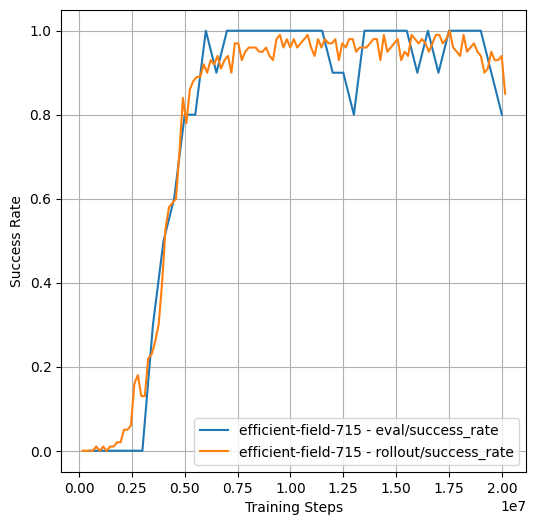

In [39]:
def plot_data(ax, data):
    #plot the data line onto the given figure
    ax.plot(data.iloc[:,0], data.iloc[:,1], label= f"{data.columns[1]}")


fig, ax = plt.subplots(figsize=(6, 6))
for data in eval_success_data:
    plot_data(ax, data)

for data in rollout_success_data:
    plot_data(ax, data)

plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Success Rate")
plt.legend()

plt.savefig( "training_metrics/eval_rollout_success_rate.png", dpi=300, bbox_inches='tight')
plt.show()

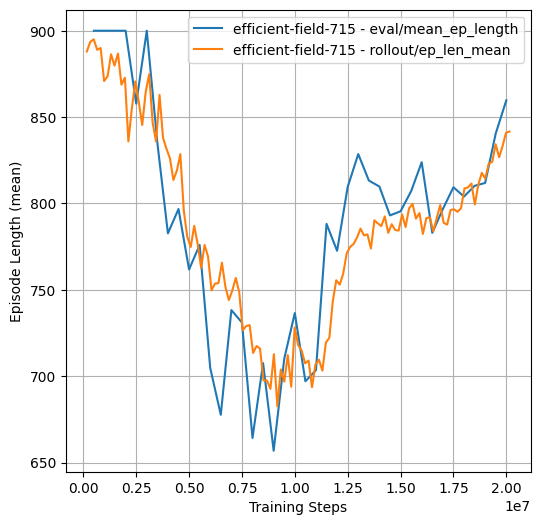

In [40]:
fig, ax = plt.subplots(figsize=(6, 6))
for data in eval_ep_len_data:
    plot_data(ax, data)

for data in rollout_ep_len_data:
    plot_data(ax, data)

plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Episode Length (mean)")
plt.legend()
plt.savefig("training_metrics/eval_rollout_episode_length.png", dpi=300, bbox_inches='tight')
plt.show()

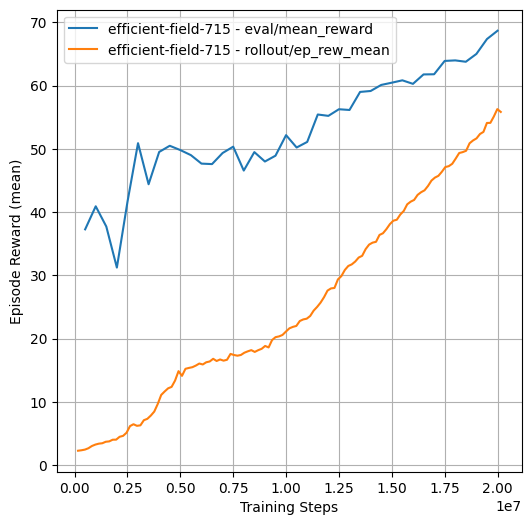

In [41]:
fig, ax = plt.subplots(figsize=(6, 6))

for data in eval_ep_rew_data:
    plot_data(ax, data)

for data in rollout_ep_rew_data:
    plot_data(ax, data)

plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Episode Reward (mean)")
plt.legend()
plt.savefig("training_metrics/eval_rollout_episode_reward.png", dpi=300, bbox_inches='tight')
plt.show()